<a href="https://colab.research.google.com/github/nickplas/Intro_to_ML_24-25/blob/main/notebooks/Lab-10.KernelPCA_KernelSVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg as LA

from scipy.spatial.distance import pdist, squareform
from scipy.linalg import eigh

Kernel regression
===============

https://knork.medium.com/linear-regression-in-python-from-scratch-with-kernels-e9c37f7975b9

**Recap**: the solution of the linear regression $y=wX$ can be also written as:

$$
w=(X^{T}X)^{-1}X^{T}y=X^{T}(XX^{T})^{-1}y
$$


Let $X\in R^{N\times d}$, then $X^{T}X\in R^{d\times d}$ and $K=XX^{T}\in R^{N\times N}$: it all depends on the ratio $\frac{d}{N}$ which matrix is more convenient (i.e. less computational demanding) to compute. 

For predictions, we plug the above for a test point $z$ and get:

$$
f(z)=z^{T}w=z^{T} X^{T}(XX^{T})^{-1}y= \alpha^{T}(z)K^{-1}y
$$

with $\alpha(z)=z^{T}X^{T}=K(z,X)\in R^{1\times N}$.

This is the case for linear regression. How can we extend to the non-linear case?  $x\rightarrow \phi(x)$, and the reasoning above repeats.


Also: https://github.com/luigicarratino/Tutorial_Kernels_MLSS2019_London/blob/master/Tutorial%20Kernel.ipynb



## Recap on different kernel functions 

See also: https://www.cs.toronto.edu/~duvenaud/cookbook/

1. **Linear Kernel**: $k(x, y) = <x, y> = x\cdot y$ fast to compute, hence convenient when there are a lot of features and no need to map points in a higher dimensional space. Usually combined with other kernels to increase their expressiveness. 

2. **Polynomial Kernel**: $k(x, y)= (1 + x\cdot y)^p$ ($p$ is the degree) non-linear function if $p>1$, it allows to cnsider interactions among features up to order $p$.

3. **Radial Basis Funtion / Gaussian Kernel**: $k(x, y) = \bigg( -\frac{||x - y||_2}{2 \sigma^2} \bigg)$ it is arguably the most used, as it can map points potentially to infinite dimenional space (think about Taylor expansion) hence it is potentially able to fit any dataset. 

In [2]:
def kernelFunc(x1, x2, kernel_type, param):
    if kernel_type == 'poly':
        return (1 + np.dot(x1, x2)) ** param
    elif kernel_type == 'rbf':
        return np.exp(- np.dot(x1-x2,x1-x2)) / (2*param)
    elif kernel_type == 'linear':
        return np.dot(x1,x2)

RBF Kernel PCA
=============

***PCA recap***

Normalization
$$
x\rightarrow x-\frac{1}{d}\sum_{j}(x)_{j}\
$$

Eigenvectors of the covariance matrix are the new coordinates (thanks to normalization):
$$
Cv=\lambda v\;\;\;\;\;\;\;C=\frac{1}{N}\sum_{i}x_{i}x^{T}_{i}
$$

The first $d$ eigenvalues provide information about the amount of information (i.e. variance) retained if we use only the first $d$ eigendirection.

<img src="http://www.nlpca.org/fig_pca_principal_component_analysis.png" alt= “” width="600" height="300">





However it may not be applicable to data at hand:

<img src="https://www.baeldung.com/wp-content/uploads/sites/4/2023/10/pca_example_1.png" alt= “” width="800" height="400">



***Kernel PCA***

**Intuition**: use a kernel function to map features in a different (often higher dimensional) feature space, then perform dimensionality reduction in this new space using PCA.

New Features
$$
x\rightarrow \phi(x)
$$

Covariance eigenvalues and eigenvectors:

$$
C_{K}v=\lambda v\;\;\;\;\;\;\;\;C_{K}=\frac{1}{N}\sum_{i}\phi(x_{i})\phi^{T}(x_{i})
$$

One can prove that eigenvectors are linear combinations of features: 

$$
v=\sum_{i}\alpha_{i}\phi(x_{i})\;\;\; \alpha_i = \frac{\phi(x_i)^T v}{N\lambda}
$$

This comes from the fact that K should be a *Gram Matrix*, which is symmetric positive definite and we search for
a low rank approximation of the Kernel. The Kernel for how it is computed is not readily a good Gram Matrix, it should undergo a process called
*Double Centering* (this is only a requirement to center the matrix around 0, requiring only a linear transformation on elements). The math behind
is quite verbose, if you want more info ask me.

Multiplying both sides of $C_{K}v=\lambda v$ by $\phi(x_{k})$ we have the following eigendecomposition:

$$
N\lambda \alpha = K \alpha
$$

Normalization
$$
\phi(x)\rightarrow \phi(x)-\frac{1}{d}\sum_{i}(\phi(x))_{i} 
$$

The resulting kernel is

$$
K\rightarrow K - \dfrac{1}{N}\mathbb{1}K - \dfrac{1}{N}K\mathbb{1} + \dfrac{1}{N}\mathbb{1}K\mathbb{1}
$$

with $\mathbb{1}$ being the matrix of all ones


See also  https://sdat.ir/en/sdat-blog/python-kernel-tricks-and-nonlinear-dimensionality-reduction-via-rbf-kernel-pca


Performing PCA in a higher dimension might be more suitable:

<img src="https://2.bp.blogspot.com/_slrAR0IXTL0/TF-OZaNbRCI/AAAAAAAAAUo/SdYS3hXd4MI/s1600/figure.png" alt= “” width="600" height="600">

Hence, given a $M\times M$ kernel matrix $K$ for a dataset of $M$ points, to get its principal components we should compute the following:

1. Center the kernel matrix by computing $K\rightarrow K-2Id_{1/n}K + Id_{1/n}K Id_{1/n}$
3. Find ordered eigenvalues and eigenvectors of $K$ 

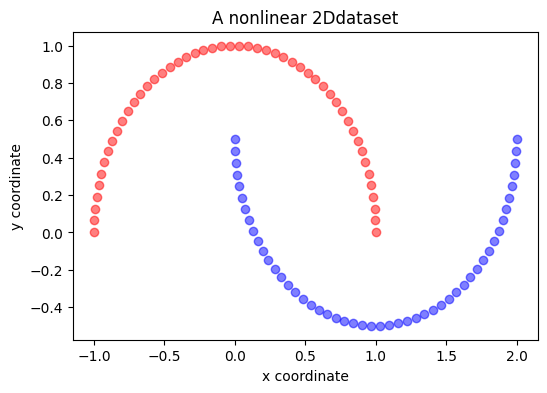

In [7]:
# very famous example of non-linearly-separable dataset
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=100, random_state=123)

plt.figure(figsize=(6,4))

plt.scatter(X[y==0, 0], X[y==0, 1], color='red', alpha=0.5)
plt.scatter(X[y==1, 0], X[y==1, 1], color='blue', alpha=0.5)

plt.title('A nonlinear 2Ddataset')
plt.ylabel('y coordinate')
plt.xlabel('x coordinate')

plt.show()

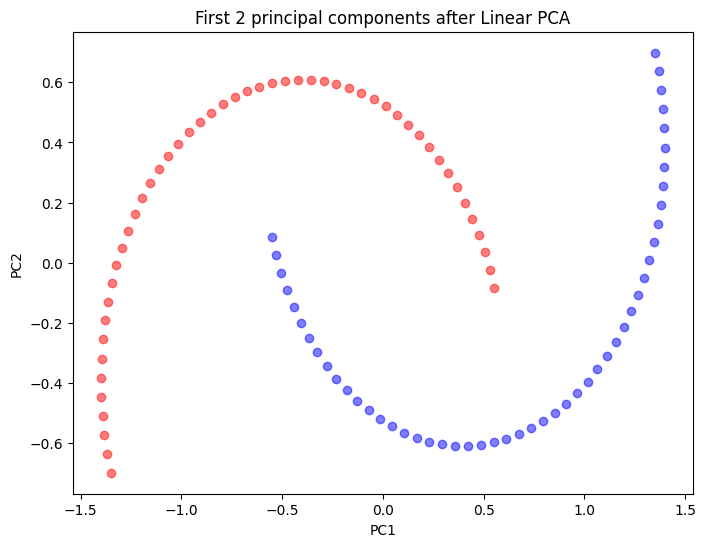

In [8]:
from sklearn.decomposition import PCA, KernelPCA

scikit_pca = PCA(n_components=2)
X_spca = scikit_pca.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(X_spca[y==0, 0], X_spca[y==0, 1], color='red', alpha=0.5)
plt.scatter(X_spca[y==1, 0], X_spca[y==1, 1], color='blue', alpha=0.5)

plt.title('First 2 principal components after Linear PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

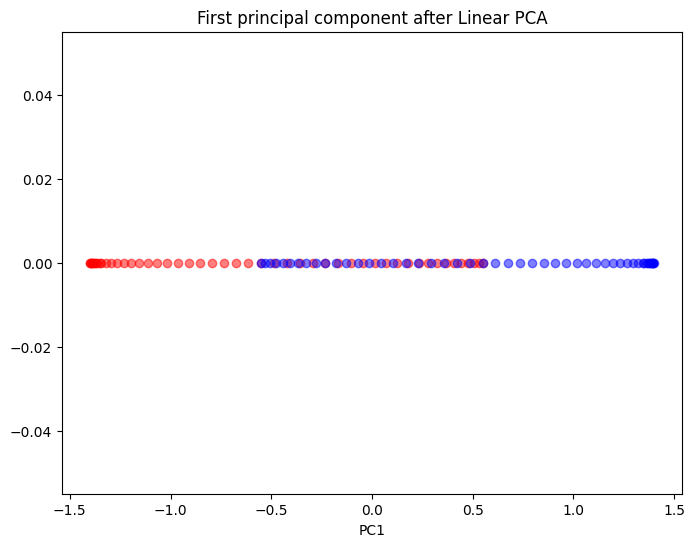

In [9]:
scikit_pca = PCA(n_components=1)
X_spca = scikit_pca.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(X_spca[y==0, 0], np.zeros((50,1)), color='red', alpha=0.5)
plt.scatter(X_spca[y==1, 0], np.zeros((50,1)), color='blue', alpha=0.5)

plt.title('First principal component after Linear PCA')
plt.xlabel('PC1')

plt.show()

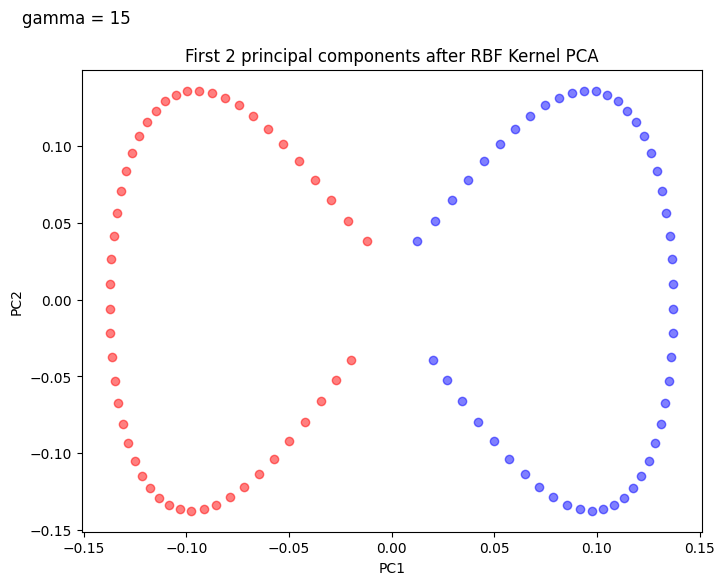

In [11]:
# more efficient implementation
def kpca(X, gamma, n_components):
    """
    Implementation of a RBF kernel PCA.

    Arguments:
        X: A MxN dataset as NumPy array where the samples are stored as rows (M),
           and the attributes defined as columns (N).
        gamma: A free parameter (coefficient) for the RBF kernel.
        n_components: The number of components to be returned.

    """
    # Calculating the squared Euclidean distances for every pair of points
    # in the MxN dimensional dataset.
    sq_dists = pdist(X, 'sqeuclidean')

    # Converting the pairwise distances into a symmetric MxM matrix.
    mat_sq_dists = squareform(sq_dists)

    # Computing the MxM kernel matrix.
    K = np.exp(-gamma * mat_sq_dists)
     

    # Centering the symmetric NxN kernel matrix.
    N = K.shape[0]
    one_n = np.ones((N,N)) / N
    K = K - one_n.dot(K) - K.dot(one_n) + one_n.dot(K).dot(one_n)

    # Obtaining eigenvalues in descending order with corresponding
    # eigenvectors from the symmetric matrix.
    eigvals, eigvecs = LA.eigh(K)

    # Obtaining the i eigenvectors that corresponds to the i highest eigenvalues.
    X_pc = np.column_stack([eigvecs[:,-i] for i in range(1,n_components+1)])

    return X_pc
X_pc = kpca(X, gamma=15, n_components=2)

plt.figure(figsize=(8,6))
plt.scatter(X_pc[y==0, 0], X_pc[y==0, 1], color='red', alpha=0.5)
plt.scatter(X_pc[y==1, 0], X_pc[y==1, 1], color='blue', alpha=0.5)

plt.title('First 2 principal components after RBF Kernel PCA')
plt.text(-0.18, 0.18, 'gamma = 15', fontsize=12)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


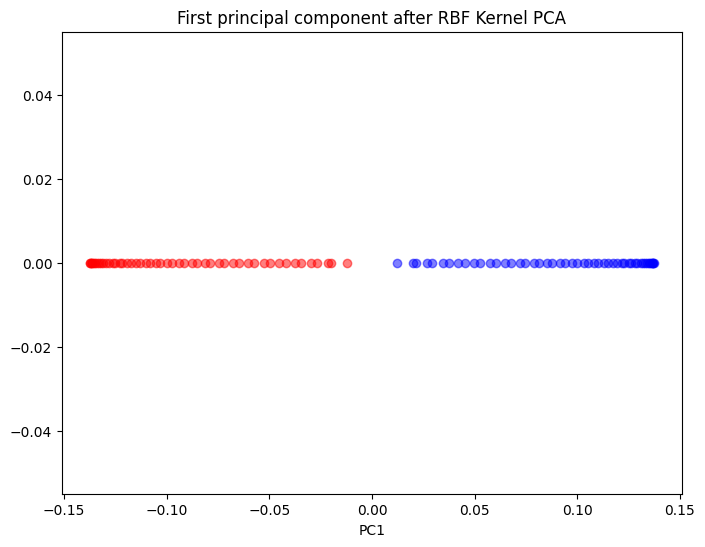

In [12]:
plt.figure(figsize=(8,6))
plt.scatter(X_pc[y==0, 0], np.zeros((50)), color='red', alpha=0.5)
plt.scatter(X_pc[y==1, 0], np.zeros((50)), color='blue', alpha=0.5)

plt.title('First principal component after RBF Kernel PCA')
plt.xlabel('PC1')
plt.show()

## Kernel SVM 

**Recall**: Suppport Vector Machines (SVM) separates data by finding an hyperplane which maximizes the margin between classes.

Kernel SVM use kernels to map data in a higher dimensional feature space, where the maximal margin hyperplane is learned. 

In [13]:
# from svm lab
def kernelFunc(x1, x2, kernel_type , param):
    """
    args:
        x_1: first component, array
        x_2: second component, array
        kernel_type: used to specify which kernel to use, string
        param: p parameter
    
    output:
        Value of the kernel 
    """
    if kernel_type == 'Pol':
        return (np.dot(x1.T,x2)+1)**param
    
    if kernel_type == 'Lin':
        return np.dot(x1.T,x2)
    if kernel_type == 'Rbf':
        return np.exp(-((np.linalg.norm(x1-x2)**2)/(2*(param**2))))

def kernel_matrix (x, y,kernel_type, param):
    n = x.shape[0]
    l = y.shape[0]
    k = np.zeros((n,l))
    for i in range(n):
        for j in range(l):
            k[i,j] = kernelFunc(x[i],y[j], kernel_type, param)
    return k

def hingeFunction(z):
    return np.maximum(1-z,0)


def hingesubgrad(z):
    g = np.zeros(z.shape)
    g[z < 1] = -1
    return g

def kReghingeLoss(K,labels,alpha, lam):
    d = np.shape(K)[0]
    L = np.mean(np.maximum(np.ones(d) - labels*(K@alpha), 0)) + lam * LA.norm(alpha,2)**2
    return L

def ksvmGrad(K, labels, alpha, lam):
    g1 = hingesubgrad(np.diag(labels)@(K@alpha))
    g2 = np.diag(labels)@K
    return g1.dot(g2) + 2*lam*alpha

    #n = len(labels)
    #margin = labels * (K @ alpha)
    #subgrad = np.zeros(n)
    #subgrad[margin < 1] = -labels[margin < 1]  # Derivata della hinge loss
    #return (subgrad @ K) / n + 2 * lam * alpha

def ksvm_training(X, labels, lam, Iter, gamma, kernel_type, param):
    # get dimensions
    d = np.shape(X)[0]
    K = kernel_matrix(X, X, kernel_type, param)
    # initialise weight vector and set first column to a random vector
    alpha = np.random.randn(d, Iter)
    alpha[:,0] = np.random.normal(0,0.01,d)
    # initialise loss vector
    L = np.zeros(Iter)

    for i in range(Iter-1):
        # update weights using subgradient descent algorithm
        alpha[:,i+1] = alpha[:,i] - gamma * ksvmGrad(K, labels, alpha[:,i], lam)

        # save loss
        L[i] = kReghingeLoss(K,labels,alpha[:,i],lam)

    return alpha, L

In [14]:
def predlabels(X, X_train ,alpha, kernel_type, param): 
    K_test = kernel_matrix(X, X_train, kernel_type, param)
    predictions = np.sign(K_test @ alpha)
    
    return predictions

# calculate accuracy
def acc(labels, predlabels):
     return np.count_nonzero(labels == predlabels)/len(labels)   

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
C = np.linspace(0.1,10,10)
p_range = []
p_range = np.concatenate([np.linspace(C[i],C[i+1],10) for i in range(len(C)-1)])
p_max = 0
acc_max = 0
for p in p_range:
    kernel_type = 'Rbf'
    alpha,L = ksvm_training(X_train, y_train, 0.01,100, 0.1,kernel_type, p)
    y_pred = predlabels(X_test,X_train,alpha[:,-1],kernel_type, p)
    if acc(y_test, y_pred) > acc_max:
        p_max = p
        acc_max = acc(y_test, y_pred)
print(p_max,acc_max)

0.1 0.48


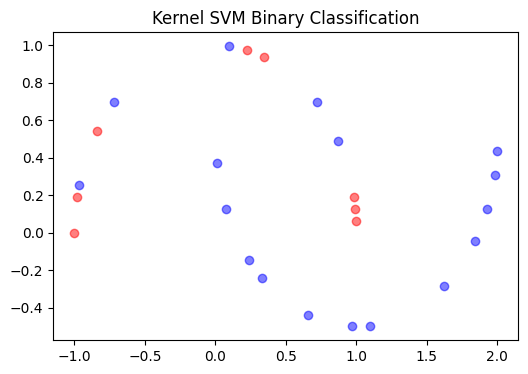

In [16]:
alpha,L = ksvm_training(X_train, y_train, 0.01,100, 0.1,kernel_type, 0.1)
y_pred = predlabels(X_test,X_train,alpha[:,-1],kernel_type, 0.01)
plt.figure(figsize=(6,4))

plt.scatter(X_test[y_pred==-1, 0], X_test[y_pred==-1, 1], color='red', alpha=0.5)
plt.scatter(X_test[y_pred==1, 0], X_test[y_pred==1, 1], color='blue', alpha=0.5)

plt.title('Kernel SVM Binary Classification')

plt.show()

**Sklearn Kernel SVM Function**

In [42]:
from sklearn.svm import SVC

svc = SVC(kernel='rbf', gamma=15)
svc.fit(X_train, y_train)
y_pred_sk = svc.predict(X_test)
print('Accuracy with sklearn: ', acc(y_test, y_pred_sk))

Accuracy with sklearn:  1.0


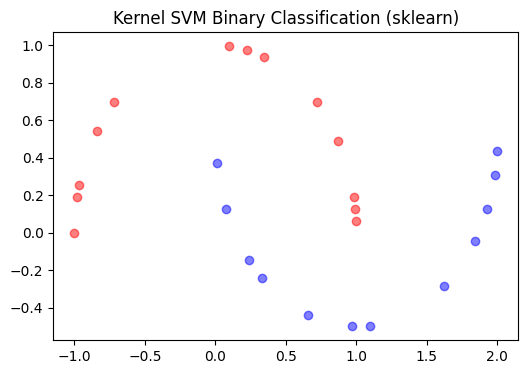

In [43]:
plt.figure(figsize=(6,4))

plt.scatter(X_test[y_pred_sk==0, 0], X_test[y_pred_sk==0, 1], color='red', alpha=0.5)
plt.scatter(X_test[y_pred_sk==1, 0], X_test[y_pred_sk==1, 1], color='blue', alpha=0.5)

plt.title('Kernel SVM Binary Classification (sklearn)')

plt.show()

## A more real life example
### The beloved MNIST dataset

The MNIST dataset (Modified National Institute of Standards and Technology) is a collection of 70,000 grayscale images of handwritten digits (0-9), each of size 28x28 pixels. It is widely used in machine learning and deep learning for image classification tasks. MNIST serves as a benchmark dataset for evaluating algorithms.

Let's see how our kernel methods work on the mnist dataset.
We will use sklearn methods.

Suggestion, choose a subset $\sim$ 10000 of those images, since otherwise you will need 200Gb of RAM :)

Tasks:

- Load MNIST dataset
- Apply classical PCA, plot the first two principal components, then visualize the eigenvectors
- Apply kernel PCA, plot the first two principal components (colour by class datapoints)
- Choose two classes (eg. 5 and 8) and build an SVM that can distinguish between them



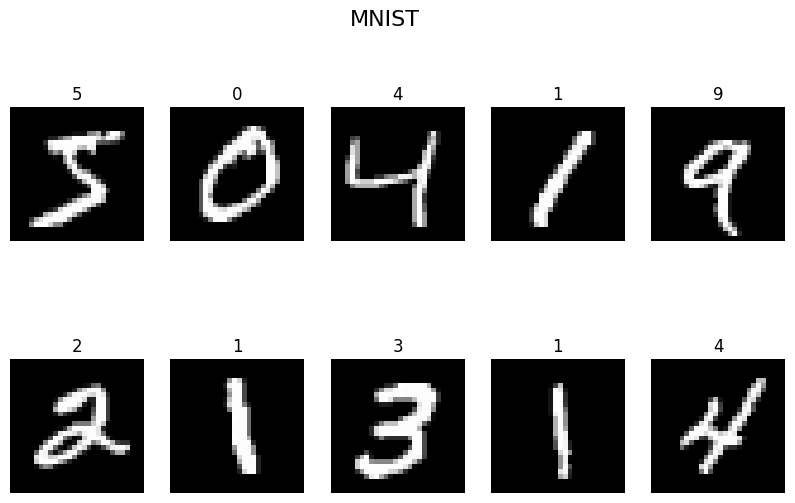

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

# Load MNIST from OpenML
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype(int)

# Plot some sample images
fig, axes = plt.subplots(2, 5, figsize=(10, 6))
fig.suptitle("MNIST", fontsize=16)

for i, ax in enumerate(axes.ravel()):
    ax.imshow(X[i].reshape(28,28), cmap='gray')
    ax.set_title(f"{y[i]}")
    ax.axis("off")

plt.show()

In [26]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
indici = [i for i, y_ in enumerate(y) if y_ == 8 or y_ == 5] 
y_5_8 = y[indici]
X_5_8 = X[indici]
X_train, X_test, y_train, y_test = train_test_split(X_5_8, y_5_8, test_size=0.25, random_state=42)

In [27]:
k = 1000
indices = np.random.choice(X_5_8.shape[0], k, replace=False)  # Estrai k indici casuali
X_subset = X_5_8[indices, :]
y_subset = y_5_8[indices]

Text(0.5, 1.0, '2D PCA Visualization')

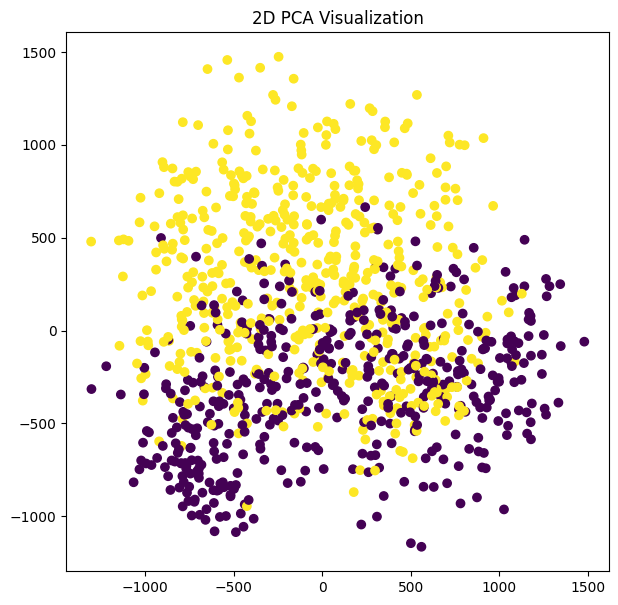

In [28]:
from sklearn.decomposition import PCA, KernelPCA
from sklearn.metrics import accuracy_score
scikit_pca = PCA(n_components=2)
X_spca = scikit_pca.fit_transform(X_subset)

#faccio il plot
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(X_spca[:, 0], X_spca[:, 1], c=y_subset)
ax.set_title('2D PCA Visualization')

Text(0.5, 1.0, '2D PCA Visualization')

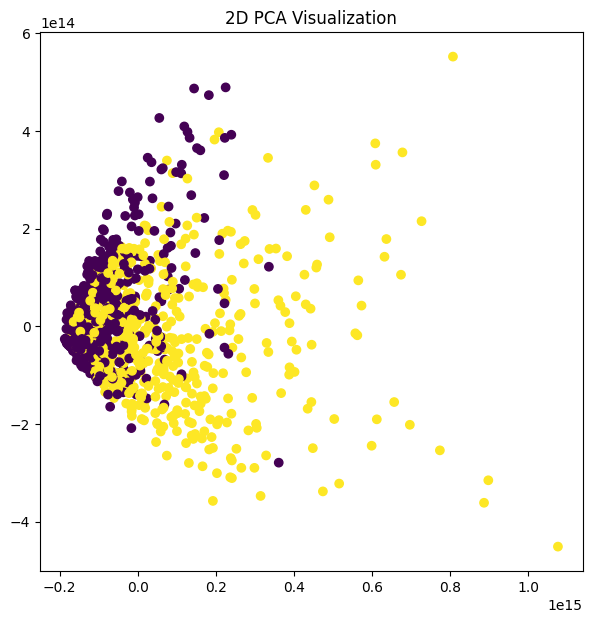

In [29]:
k_pca = KernelPCA(kernel='poly', gamma=1000, alpha=1)
kX_spca = k_pca.fit_transform(X_subset)
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(kX_spca[:, 0], kX_spca[:, 1], c= y_subset)
ax.set_title('2D PCA Visualization')

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X_spca, y_subset, test_size=0.25, random_state=42)
svc = SVC()
svc.fit(X_train,y_train)
y_pred = svc.predict(X_test)
print('Accuracy with sklearn: ', accuracy_score(y_test, y_pred))

Accuracy with sklearn:  0.788


In [32]:
X_train, X_test, y_train, y_test = train_test_split(kX_spca, y_subset, test_size=0.25, random_state=42)
svc = SVC()
svc.fit(X_train,y_train)
y_pred = svc.predict(X_test)
print('Accuracy with sklearn: ', accuracy_score(y_test, y_pred))

Accuracy with sklearn:  0.984
